## Human-Synthetic Comparision Spam Detection Using Logistic Regression / SVM

In [1]:
# Importing necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder


Step 2: Load and Preprocess the Dataset

In [2]:
# Load the dataset
data = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'message'])

# Display the first few rows to check the dataset structure
data.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Step 3: Data Preprocessing (Clean the Text)

In [3]:
# Function to clean the messages (lowercase, remove punctuation, etc.)
import re

def clean_text(text):
    text = text.lower()  # Convert text to lowercase
    text = re.sub(r'\d+', '', text)  # Remove digits
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Clean the messages
data['cleaned_message'] = data['message'].apply(clean_text)
data.head()


,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


Step 4: Encode the Labels (Spam/Not Spam)

In [4]:
# Encode the labels: spam = 1, ham = 0
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])


Step 5: Split Data into Training and Testing Sets

In [5]:
# Split data into features (X) and labels (y)
X = data['cleaned_message']
y = data['label']

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the size of training and testing datasets
len(X_train), len(X_test)


(4457, 1115)

Step 6: Convert Text to TF-IDF Vectors

In [6]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform the training data, and transform the testing data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Check the shape of the transformed data
X_train_tfidf.shape, X_test_tfidf.shape


((4457, 5000), (1115, 5000))

Step 7: Train the Model Using Logistic Regression or SVM
Logistic Regression Model:

In [7]:
# Initialize Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000)

# Train the Logistic Regression model
logreg_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [8]:
# Initialize Support Vector Machine (SVM) model
svm_model = SVC(kernel='linear')

# Train the SVM model
svm_model.fit(X_train_tfidf, y_train)


SVC(kernel='linear')

Step 8: Make Predictions

In [9]:
# Make predictions using Logistic Regression
logreg_preds = logreg_model.predict(X_test_tfidf)

# Make predictions using SVM
svm_preds = svm_model.predict(X_test_tfidf)


Step 9: Evaluate Model Performance
Logistic Regression Evaluation:

In [10]:
# Evaluate Logistic Regression model
logreg_accuracy = accuracy_score(y_test, logreg_preds)
logreg_report = classification_report(y_test, logreg_preds)

print("Logistic Regression Accuracy: ", logreg_accuracy)
print("Logistic Regression Classification Report:")
print(logreg_report)


Logistic Regression Accuracy:  0.9659192825112107
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [11]:
# Evaluate SVM model
svm_accuracy = accuracy_score(y_test, svm_preds)
svm_report = classification_report(y_test, svm_preds)

print("SVM Accuracy: ", svm_accuracy)
print("SVM Classification Report:")
print(svm_report)


SVM Accuracy:  0.9901345291479821
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       1.00      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [12]:
# Compare the results
print("Logistic Regression vs SVM Performance")
print(f"Logistic Regression Accuracy: {logreg_accuracy}")
print(f"SVM Accuracy: {svm_accuracy}")


Logistic Regression vs SVM Performance
Logistic Regression Accuracy: 0.9659192825112107
SVM Accuracy: 0.9901345291479821


# Spam Detection on Synthetic Dataset using Logistic Regression & SVM

In [13]:
df_syn = pd.read_csv("Merged_Cleaned_Synthetic_SMSSpamCollection.csv", sep="\t")
print(df_syn.head())



  label                                            message
0   ham  and watch a film about a guy named Bill. They'...
1   ham  and get some dinner, but I'm just not sure how...
2   ham  How about something like this one? Thank you! ...
3   ham                                          at 6 a.m.
4  spam  to play your favourite MMO in one of our exclu...


In [14]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

df_syn['cleaned_message'] = df_syn['message'].apply(clean_text)


In [15]:
label_encoder_syn = LabelEncoder()
df_syn['label_encoded'] = label_encoder_syn.fit_transform(df_syn['label'])


In [16]:
X_syn = df_syn['cleaned_message']
y_syn = df_syn['label_encoded']

X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train_syn)} | Test size: {len(X_test_syn)}")


Train size: 3682 | Test size: 921


In [17]:
tfidf_syn = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf_syn = tfidf_syn.fit_transform(X_train_syn)
X_test_tfidf_syn = tfidf_syn.transform(X_test_syn)

print(X_train_tfidf_syn.shape, X_test_tfidf_syn.shape)


(3682, 3543) (921, 3543)


In [18]:
logreg_syn = LogisticRegression(max_iter=1000)
logreg_syn.fit(X_train_tfidf_syn, y_train_syn)


LogisticRegression(max_iter=1000)

In [19]:
svm_syn = SVC(kernel='linear')
svm_syn.fit(X_train_tfidf_syn, y_train_syn)


SVC(kernel='linear')

In [20]:
logreg_preds_syn = logreg_syn.predict(X_test_tfidf_syn)
svm_preds_syn = svm_syn.predict(X_test_tfidf_syn)


In [21]:
logreg_acc_syn = accuracy_score(y_test_syn, logreg_preds_syn)
logreg_report_syn = classification_report(y_test_syn, logreg_preds_syn, target_names=['Ham', 'Spam'])

print("🔍 Logistic Regression Accuracy (Synthetic):", logreg_acc_syn)
print("Classification Report:\n", logreg_report_syn)


🔍 Logistic Regression Accuracy (Synthetic): 0.9087947882736156
Classification Report:
               precision    recall  f1-score   support

         Ham       0.90      0.97      0.93       614
        Spam       0.94      0.78      0.85       307

    accuracy                           0.91       921
   macro avg       0.92      0.88      0.89       921
weighted avg       0.91      0.91      0.91       921



In [22]:
svm_acc_syn = accuracy_score(y_test_syn, svm_preds_syn)
svm_report_syn = classification_report(y_test_syn, svm_preds_syn, target_names=['Ham', 'Spam'])

print("🔍 SVM Accuracy (Synthetic):", svm_acc_syn)
print("Classification Report:\n", svm_report_syn)


🔍 SVM Accuracy (Synthetic): 0.9294245385450597
Classification Report:
               precision    recall  f1-score   support

         Ham       0.92      0.97      0.95       614
        Spam       0.94      0.84      0.89       307

    accuracy                           0.93       921
   macro avg       0.93      0.91      0.92       921
weighted avg       0.93      0.93      0.93       921



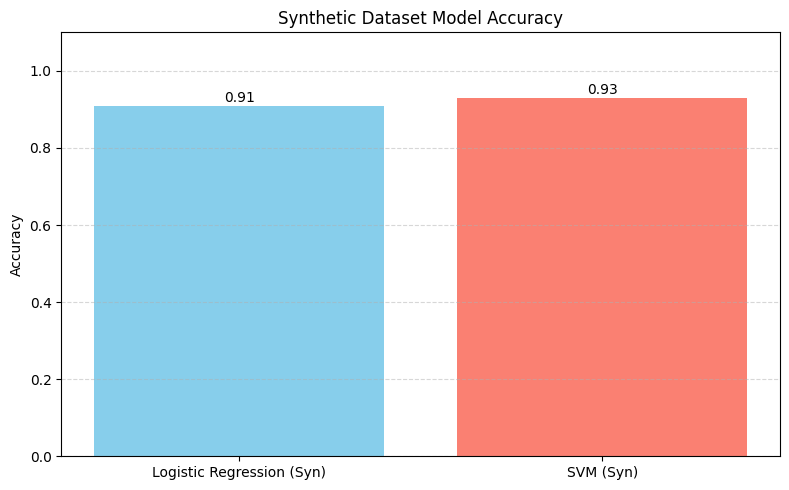

In [23]:
import matplotlib.pyplot as plt

models_syn = ['Logistic Regression (Syn)', 'SVM (Syn)']
accuracies_syn = [logreg_acc_syn, svm_acc_syn]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_syn, accuracies_syn, color=['skyblue', 'salmon'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center')

plt.title('Synthetic Dataset Model Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [28]:
# Vectorize original test messages using synthetic TF-IDF vectorizer
X_test_tfidf_syn_on_orig = tfidf_syn.transform(X_test)

# Make predictions using synthetic-trained Logistic Regression on original test set
logreg_preds_syn_on_orig = logreg_syn.predict(X_test_tfidf_syn_on_orig)

# Make predictions using synthetic-trained SVM on original test set
svm_preds_syn_on_orig = svm_syn.predict(X_test_tfidf_syn_on_orig)


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ORIGINAL DATASET METRICS
logreg_metrics_orig = {
    'Accuracy': accuracy_score(y_test, logreg_preds),
    'Precision': precision_score(y_test, logreg_preds),
    'Recall': recall_score(y_test, logreg_preds),
    'F1 Score': f1_score(y_test, logreg_preds)
}

svm_metrics_orig = {
    'Accuracy': accuracy_score(y_test, svm_preds),
    'Precision': precision_score(y_test, svm_preds),
    'Recall': recall_score(y_test, svm_preds),
    'F1 Score': f1_score(y_test, svm_preds)
}

# SYNTHETIC DATASET METRICS
logreg_metrics_syn = {
    'Accuracy': accuracy_score(y_test_syn, logreg_preds_syn),
    'Precision': precision_score(y_test_syn, logreg_preds_syn),
    'Recall': recall_score(y_test_syn, logreg_preds_syn),
    'F1 Score': f1_score(y_test_syn, logreg_preds_syn)
}

svm_metrics_syn = {
    'Accuracy': accuracy_score(y_test_syn, svm_preds_syn),
    'Precision': precision_score(y_test_syn, svm_preds_syn),
    'Recall': recall_score(y_test_syn, svm_preds_syn),
    'F1 Score': f1_score(y_test_syn, svm_preds_syn)
}

# TEST SYNTHETIC MODEL ON ORIGINAL TEST SET METRICS
logreg_metrics_syn_on_orig = {
    'Accuracy': accuracy_score(y_test, logreg_preds_syn_on_orig),
    'Precision': precision_score(y_test, logreg_preds_syn_on_orig),
    'Recall': recall_score(y_test, logreg_preds_syn_on_orig),
    'F1 Score': f1_score(y_test, logreg_preds_syn_on_orig)
}

svm_metrics_syn_on_orig = {
    'Accuracy': accuracy_score(y_test, svm_preds_syn_on_orig),
    'Precision': precision_score(y_test, svm_preds_syn_on_orig),
    'Recall': recall_score(y_test, svm_preds_syn_on_orig),
    'F1 Score': f1_score(y_test, svm_preds_syn_on_orig)
}

In [30]:
comparison_df = pd.DataFrame({
    'LogReg_Original': logreg_metrics_orig,
    'SVM_Original': svm_metrics_orig,
    'LogReg_Synthetic': logreg_metrics_syn,
    'SVM_Synthetic': svm_metrics_syn,
    'LogReg_Synthetic_on_OriginalTest': logreg_metrics_syn_on_orig,
    'SVM_Synthetic_on_OriginalTest': svm_metrics_syn_on_orig
})

print("🔍 Model Comparison: Original vs Synthetic Datasets & Synthetic Model on Original Test Set")
display(comparison_df.round(4))


🔍 Model Comparison: Original vs Synthetic Datasets & Synthetic Model on Original Test Set


,LogReg_Original,SVM_Original,LogReg_Synthetic,SVM_Synthetic,LogReg_Synthetic_on_OriginalTest,SVM_Synthetic_on_OriginalTest
Accuracy,0.9659,0.9901,0.9088,0.9294,0.9085,0.9031
Precision,1.0000,1.0000,0.9373,0.9416,0.7374,0.6752
Recall,0.7450,0.9262,0.7785,0.8404,0.4899,0.5302
F1 Score,0.8538,0.9617,0.8505,0.8881,0.5887,0.5940


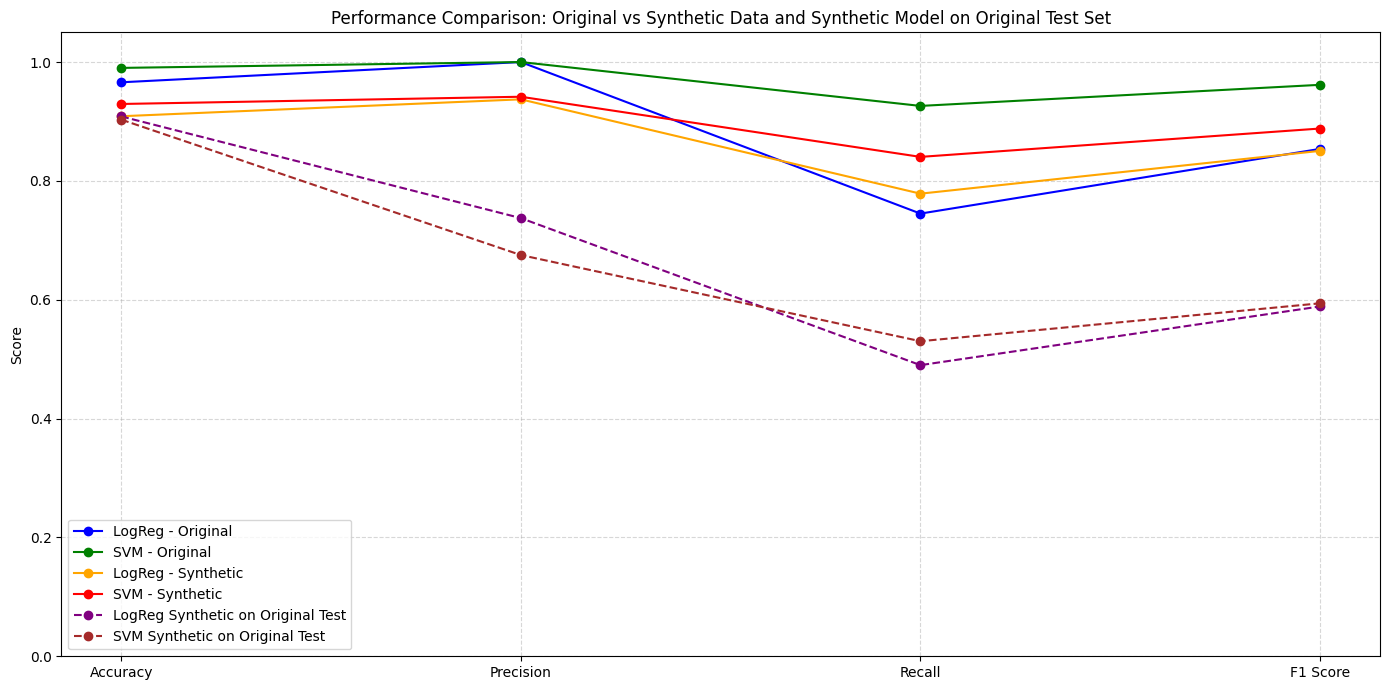

In [31]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = range(len(metrics))

plt.figure(figsize=(14, 7))

plt.plot(x, [logreg_metrics_orig[m] for m in metrics], marker='o', label='LogReg - Original', color='blue')
plt.plot(x, [svm_metrics_orig[m] for m in metrics], marker='o', label='SVM - Original', color='green')
plt.plot(x, [logreg_metrics_syn[m] for m in metrics], marker='o', label='LogReg - Synthetic', color='orange')
plt.plot(x, [svm_metrics_syn[m] for m in metrics], marker='o', label='SVM - Synthetic', color='red')
plt.plot(x, [logreg_metrics_syn_on_orig[m] for m in metrics], marker='o', label='LogReg Synthetic on Original Test', color='purple', linestyle='--')
plt.plot(x, [svm_metrics_syn_on_orig[m] for m in metrics], marker='o', label='SVM Synthetic on Original Test', color='brown', linestyle='--')

plt.xticks(x, metrics)
plt.ylim(0.0, 1.05)
plt.ylabel('Score')
plt.title('Performance Comparison: Original vs Synthetic Data and Synthetic Model on Original Test Set')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
